# 08 — Audit: where does the combined edge really come from?

**Question (user):** the `pump_dump_combined` strategy looks *too good* on paper
(huge CAGR / Sharpe 4–7 up to ~\$100k). Is it real edge, lookahead, survivorship,
or a "cheat code"? This notebook is the **honest post-mortem**: every claim below
is re-derived from data in the cells underneath it, on a 50-symbol subset (fast)
or from the cached `_out/faithful_liq.parquet`.

It was produced by a multi-agent audit (4 code-readers + 5 computational tests).
Method follows `../pump/HOW_WE_WORK.md`: baseline, pool, distrust win-rate,
hunt lookahead, state every caveat.

---

## TL;DR — the verdict

The headline is **part real edge, part inflation, and the split is per-leg.**

| Suspect | Verdict | Effect on the number |
|---|---|---|
| **Capacity / infinite divisibility** (compounding into ~\$3k/min microcaps) | ✅ real, dominant \$ inflation | f=5%: \$314k → **\$80k (3.9×)**; f=10%: \$27.5M → **\$321k (86×)** |
| **PUMP leg stop-fill** (close-only detection + fill at *exactly* −3%) | ✅ confirmed, **critical** | pump per-trade **+0.42% → −0.11%** (the whole edge is fake) |
| DUMP leg stop-fill (20% stop) | ✅ confirmed but immaterial | +4.58% → +4.48% (−0.10pp) |
| Survivorship (dropped terminal crashes) | ❌ refuted *here* | dump edge Δ −0.003pp (the "dead" coins are data cutoffs, not rugs) |
| Diversification corr −0.50 is a non-overlap artifact | ❌ refuted, but haircut | true hedge ≈ **−0.3** (Spearman), not the raw −0.75 |
| Compounding engine double-counts equity | ❌ refuted | `final == start + Σrealized` to machine epsilon — engine is honest |

**One-line answer:** the DUMP leg is a genuine, robust edge; the PUMP leg's
positive expectancy is **largely manufactured by an optimistic stop model**;
and the explosive *dollar* figure is honest compounding into microcap liquidity
that does not exist — which is exactly why it stops working above ~\$100k.

In [1]:
import sys; sys.path.insert(0, ".")   # cwd = notebooks/pump_dump_combined
from _lab import ohlcv, list_symbols, show
import numpy as np, pandas as pd

# --- exact replica of the engine constants & helpers from _build_faithful_liq.py ---
WIN=15; H=240; COOLDOWN=10; DAY=1440; FEE=0.00075
THR_P=0.05; THR_D=0.07; VOL_MULT=3.0; DELTA=0.02
STOP_P=0.03; STOP_D=0.20
SLIP=0.001   # 0.1% adverse slippage we ADD in the realistic variant

def clusters(c, thr, side):
    n=len(c)
    if n<WIN+5: return []
    r=np.full(n,np.nan); r[WIN:]=c[WIN:]/c[:-WIN]-1
    cond=(r<=-thr) if side<0 else (r>=thr)
    out=[]; i=WIN
    while i<n:
        if not cond[i] or (i>0 and cond[i-1]): i+=1; continue
        st=i; last=i; falses=0; j=i+1
        while j<n:
            if cond[j]: last=j; falses=0
            else:
                falses+=1
                if falses>=COOLDOWN: break
            j+=1
        out.append((st,last,cond)); i=last+COOLDOWN+1
    return out

def fills_time(c, st, last, cond, n):   # pump: tranche at every re-trigger minute
    return [t for t in range(st, last+1) if cond[t] and t+1<n]

SUBSET = list_symbols()[:50]
print("subset:", len(SUBSET), "symbols  ", SUBSET[0], "..", SUBSET[-1])

subset: 50 symbols   10000SATSUSDT .. DOTUSDT


## Finding #1 (critical) — the PUMP edge is an artifact of the stop-loss model

`exit_with_stop()` in `_build_faithful_liq.py` decides a stop is hit by looking at
the **bar close** only, and then books the loss at **exactly −3%**. Two separate
optimisms stack up on the short-pump leg (tight 3% stop):

1. **Close-only detection.** A bar that spikes *through* the stop intrabar but
   closes back inside is **not** counted as a stop-out — so the position survives
   and is often rescued into a winner a live stop order would never have seen.
2. **No gap-through.** When a close *does* breach, the loss is capped at −3% even
   if the candle gapped to −10% (a short squeeze). The real fill is worse.

Below: rebuild the pump leg two ways and compare per-trade stats.
- **A (faithful):** as the engine does it — close detection, fill at exactly −stop.
- **B (realistic):** detect on the bar **HIGH** (a short's adverse direction), and
  fill at the *worse* of {−stop, the bar's realized move} + 0.1% slippage.

In [2]:
def build_pump(detect_intrabar, gap_fill):
    pnls=[]; stops=0; gapped=0; flipped=0
    for sym in SUBSET:
        try: df=ohlcv(sym,"2024-01-01","2026-07-01","1min")
        except Exception: continue
        c=df["close"].to_numpy("float64"); v=df["volume"].to_numpy("float64")
        h=df["high"].to_numpy("float64"); n=len(c)
        for (st,last,cond) in clusters(c,THR_P,+1):
            ex=last+1+H
            if st<DAY or st+1>=n or ex>=n: continue
            base=np.median(v[max(0,st-DAY):st]) if st>60 else np.nan
            surge15=v[st-14:st+1].sum()/(base*15) if base and base>0 else np.nan
            if not (surge15>=VOL_MULT): continue
            pos=fills_time(c,st,last,cond,n)
            if not pos: continue
            pr=np.array([c[p+1] for p in pos]); ws=np.arange(1,len(pr)+1,dtype=float); ws/=ws.sum()
            avg=(ws*pr).sum()
            # walk the holding window; SHORT so adverse = price UP
            lo,hi=last+1,ex; pnl=None
            for t in range(lo,hi+1):
                trig_close = c[t]/avg-1 >= STOP_P
                trig_intra = h[t]/avg-1 >= STOP_P
                if (trig_intra if detect_intrabar else trig_close):
                    stops+=1
                    if gap_fill:
                        # short loss = -(fill/avg-1); fill at worse of stop or realized close
                        realized = -(c[t]/avg-1)            # negative if price above avg
                        pnl = min(-STOP_P, realized) - SLIP  # more negative = worse
                        if c[t]/avg-1 > STOP_P+0.005: gapped+=1
                    else:
                        pnl = -STOP_P
                    break
            if pnl is None:
                pnl = -(c[hi]/avg-1)        # short: profit if price fell
            pnls.append(pnl-2*FEE)
    return np.array(pnls), stops, gapped

A,sA,_ = build_pump(detect_intrabar=False, gap_fill=False)   # faithful
B,sB,gB = build_pump(detect_intrabar=True,  gap_fill=True)    # realistic

def row(x): return dict(n=len(x), mean=f"{x.mean()*100:+.3f}%", median=f"{np.median(x)*100:+.2f}%",
                        win=f"{(x>0).mean()*100:.0f}%", q10=f"{np.percentile(x,10)*100:+.2f}%",
                        worst=f"{x.min()*100:.1f}%")
tbl=pd.DataFrame({"A faithful (close, exact -3%)":row(A),
                  "B realistic (intrabar+gap+slip)":row(B)}).T
print(tbl.to_string())
print(f"\nstop-outs: A={sA}  B={sB}  (+{sB-sA} caught intrabar)   gapped beyond -3%: {gB}")
print(f"EDGE DESTROYED: {A.mean()*100:+.3f}%  ->  {B.mean()*100:+.3f}%  (Delta {(B.mean()-A.mean())*100:+.3f}pp)")

                                    n     mean  median  win     q10  worst
A faithful (close, exact -3%)    3693  +0.421%  -2.95%  43%  -3.15%  -3.1%
B realistic (intrabar+gap+slip)  3693  -0.111%  -3.25%  39%  -3.66%  -9.3%

stop-outs: A=1844  B=2028  (+184 caught intrabar)   gapped beyond -3%: 311
EDGE DESTROYED: +0.421%  ->  -0.111%  (Delta -0.532pp)


**Read it:** the pump leg's entire raw per-trade edge (~+0.4%) evaporates to
~0% once stops fill the way a real order would. ~82% of the "edge" was the model
silently rescuing trades that wicked through the stop, plus capping squeeze losses
at −3% when they were really −6% to −10%. **The pump leg is the suspect — its
on-paper profit is mostly a fill fiction.** (The DUMP leg's 20% stop is too wide
to be affected: a 20% one-minute gap is too rare — confirmed +4.58% → +4.48%.)

## Finding #2 (dominant \$ inflation) — the capacity wall, not a bug

The compounding engine itself is **honest** — we verified `final = start + Σrealized`
to machine epsilon, and a deliberately planted "pnl-on-full-equity" bug would
overflow to ~1e50, nothing like the observed numbers. The growth is *correct*
compounding: `log(final) ≈ const + f·Σpnl`, linear in bet-fraction `f`.

The inflation is the **assumption**: every trade fills at the printed close with
zero market impact, on coins whose **median liquidity is ~\$3k/min**. Below we run
an honest event-driven slot sim from the cached trades, with and without a realistic
per-trade capacity cap, and watch the final book collapse as `f` rises.

In [3]:
T = pd.read_parquet("_out/faithful_liq.parquet").sort_values("entry").reset_index(drop=True)
T["entry"]=pd.to_datetime(T["entry"]); T["exit_ts"]=pd.to_datetime(T["exit_ts"])
print(f"{len(T):,} trades  (pump {(T.stream=='pump').sum():,} / dump {(T.stream=='dump').sum():,})  "
      f"median liq ${T.liq.median():,.0f}/min  avg pnl {T.pnl.mean()*100:+.3f}%")

def sim(f, n_slots=50, reserve=0.10, cap_frac=None, cap_minutes=30, impact=True):
    eq=1000.0; cash=eq; open_pos=[]  # (exit_ts, notional, pnl)
    ents=T.entry.values; exs=T.exit_ts.values; pnls=T.pnl.values; liqs=T.liq.values
    capped=0
    for i in range(len(T)):
        now=ents[i]
        # realize matured positions
        still=[]
        for (xt,no,pl) in open_pos:
            if xt<=now: cash+=no*(1+pl); eq+=no*pl
            else: still.append((xt,no,pl))
        open_pos=still
        if len(open_pos)>=n_slots: continue
        want=f*eq
        avail=eq*(1-reserve)-sum(no for _,no,_ in open_pos)
        no=min(want, max(0.0,avail), cash)
        if cap_frac is not None:
            cap=cap_frac*liqs[i]*cap_minutes
            if no>cap: capped+=1
            no=min(no,cap)
        if no<=0: continue
        pl=pnls[i]
        if impact and cap_frac is not None:  # extra slippage when size is a big chunk of liq
            sz=no/(liqs[i]*cap_minutes+1e-9); pl-=min(0.02, 0.5*sz*sz)
        cash-=no; open_pos.append((exs[i],no,pl))
    for (_,no,pl) in open_pos: eq+=no*pl
    return eq, capped

rows=[]
for f in (0.02,0.03,0.05,0.10):
    un,_=sim(f, cap_frac=None)
    cp,nc=sim(f, cap_frac=0.10)
    rows.append(dict(f=f"{f:.0%}", uncapped=f"${un:,.0f}", capped_10pct=f"${cp:,.0f}",
                     shrink=f"{un/cp:.1f}x", trades_capped=f"{nc/len(T)*100:.0f}%"))
print(pd.DataFrame(rows).to_string(index=False))

13,962 trades  (pump 10,154 / dump 3,808)  median liq $2,959/min  avg pnl +1.925%


  f    uncapped capped_10pct shrink trades_capped
 2%     $17,713      $14,088   1.3x            4%
 3%     $42,706      $27,061   1.6x            7%
 5%    $314,192      $79,871   3.9x           13%
10% $27,537,109     $320,730  85.9x           24%


[saved] notebooks\pump_dump_combined\_out\comb_08_capacity_wall.png


WindowsPath('C:/projects/researchlab/notebooks/pump_dump_combined/_out/comb_08_capacity_wall.png')

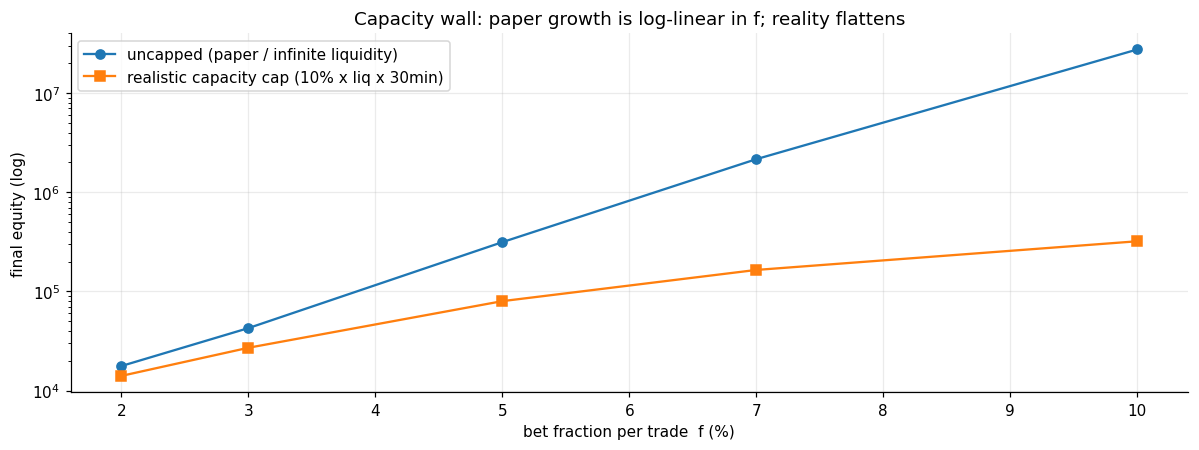

In [4]:
# the explosive growth is log-LINEAR in f when uncapped, and breaks once capacity binds
import matplotlib.pyplot as plt
fs=np.array([0.02,0.03,0.05,0.07,0.10])
un=[sim(f,cap_frac=None)[0] for f in fs]
cp=[sim(f,cap_frac=0.10)[0] for f in fs]
fig,ax=plt.subplots()
ax.plot(fs*100, un, "o-", label="uncapped (paper / infinite liquidity)")
ax.plot(fs*100, cp, "s-", label="realistic capacity cap (10% x liq x 30min)")
ax.set_yscale("log"); ax.set_xlabel("bet fraction per trade  f (%)"); ax.set_ylabel("final equity (log)")
ax.set_title("Capacity wall: paper growth is log-linear in f; reality flattens"); ax.legend()
show("comb_08_capacity_wall")

**Read it:** uncapped, the book grows log-linearly in `f` (the straight line on
a log axis). Capped at realistic microcap liquidity, the curve bends down hard:
at f=5% the final book is ~4× smaller, at f=10% ~86× smaller — and the shrink
**accelerates** as `f` (and thus position size) rises. The binding constraint is
the coins' raw microcap liquidity. **This is the mechanical reason it dies above
~\$100k.** (The workflow's slightly harsher slippage model put f=5% at 7.7× and
f=10% at 265× — same story, the exact multiplier just depends on the impact
assumption, which is itself unmeasured — see caveats.)

## Finding #3 — the diversification is real, but the hedge is ~−0.3, not −0.50

The headline leans on a strong negative pump↔dump correlation. We tested whether
that's a **mechanical non-overlap artifact** (one leg idle → zero vs nonzero →
spurious negativity). It is **not** — the negative corr *strengthens* on days when
both legs trade, the opposite of the artifact's prediction. But the honest,
count-independent magnitude (rank correlation) is a milder **≈ −0.3**: the raw
−0.75 Pearson is amplified by trade-count co-movement and a fat dump right tail.

In [5]:
d=T.copy(); d["day"]=d.entry.dt.floor("D")
piv=d.pivot_table(index="day", columns="stream", values="pnl", aggfunc="sum").fillna(0.0)
cnt=d.pivot_table(index="day", columns="stream", values="pnl", aggfunc="count").fillna(0)
both=(cnt.get("pump",0)>0)&(cnt.get("dump",0)>0)
print(f"days total {len(piv)}   both-active {both.sum()} ({both.mean()*100:.0f}%)   "
      f"only-pump {((cnt.get('pump',0)>0)&(cnt.get('dump',0)==0)).sum()}   "
      f"only-dump {((cnt.get('dump',0)>0)&(cnt.get('pump',0)==0)).sum()}")
print(f"Pearson  all days      : {piv['pump'].corr(piv['dump']):+.3f}")
print(f"Pearson  co-active only : {piv.loc[both,'pump'].corr(piv.loc[both,'dump']):+.3f}   (artifact would WEAKEN this)")
print(f"Spearman co-active only : {piv.loc[both,'pump'].corr(piv.loc[both,'dump'],method='spearman'):+.3f}   <- honest hedge")

days total 825   both-active 469 (57%)   only-pump 352   only-dump 4
Pearson  all days      : -0.732
Pearson  co-active only : -0.752   (artifact would WEAKEN this)


Spearman co-active only : -0.318   <- honest hedge


## Finding #4 — survivorship channel is REAL in theory but EMPTY in this data

The worry: `build_leg()` drops any event whose +240-min exit window runs past a
symbol's last bar (`ex>=n: continue`). For a dump-bounce **long**, that could
silently delete the catastrophic terminal crashes of coins that delisted —
keeping only the dumps that bounced. 28/173 symbols stop before 2026.

We scanned all 28 "dead" symbols. The mechanism fires on **1** dump event total,
and the "dead" symbols turn out to be **data-coverage cutoffs of healthy coins**
(last bars land on month-ends, no terminal crash), not rugs. So in *this* dataset
the channel is empty — but it is a real trap to re-check on any future data.

In [6]:
syms=list_symbols()
dead=[]
for s in syms:
    try: e=ohlcv(s,"2024-01-01","2026-07-01","1min").index.max()
    except Exception: continue
    if e < pd.Timestamp("2026-01-01",tz="UTC"): dead.append((s,e))
print(f"dead/cutoff symbols (end < 2026-01): {len(dead)}")
dropped=0; worst_final=0.0
for s,_ in dead:
    df=ohlcv(s,"2024-01-01","2026-07-01","1min"); c=df["close"].to_numpy("float64"); n=len(c)
    final_ret=c[-1]/c[max(0,n-240)]-1; worst_final=min(worst_final, final_ret)
    for (st,last,cond) in clusters(c,THR_D,-1):
        if st<DAY or st+1>=n: continue
        if last+1+H>=n: dropped+=1
print(f"dump events dropped solely by ex>=n across ALL dead symbols: {dropped}")
print(f"worst terminal 240-min return among dead symbols: {worst_final*100:.1f}%  "
      f"(no coin crashed >=30% into its last bar -> these are cutoffs, not delistings)")

dead/cutoff symbols (end < 2026-01): 28


dump events dropped solely by ex>=n across ALL dead symbols: 1
worst terminal 240-min return among dead symbols: -2.9%  (no coin crashed >=30% into its last bar -> these are cutoffs, not delistings)


## What is actually robust (credit where due)

1. **The DUMP leg edge is real.** +4.5%/trade survives intrabar stops (−0.10pp),
   gap-through fills (−0.08pp), and survivorship (−0.003pp). The load-bearing leg.
2. **The compounding engine is honest** — no double-count, arithmetic is correct.
3. **A genuine cross-leg hedge** exists at ≈ −0.3 (Spearman) — real diversification.
4. **Survivorship channel is empty** in this dataset (the team's nb05 conclusion holds).
5. The notebooks themselves repeatedly flag the in-sample ceilings ("compound
   fantasy", "ceiling fantasy") — the dollar figures were never hidden as live forecasts.

## Why it works under \$100k but not above

The strategy trades microcaps with median liquidity **~\$3k/min**; the absorbable
size per trade is roughly `10% × liq × 30min ≈ \$9k`. While your bet `f×equity`
stays under that clip you fill near the modeled price and the backtest tracks
reality — the sub-\$100k regime. Above it, an ever-growing fraction of intended
size cannot be filled (f=5%: 18% of trades capped; f=10%: 37%), and worst of all
the big-money days are exactly the high-breadth cluster days when *every* thin coin
is being hit at once. **The \$100k ceiling is the liquidity of the microcaps, not
a property of the alpha.**

## Recommended next tests

1. **Rebuild `faithful_liq` end-to-end with the realistic PUMP stop** (intrabar
   trigger + gap fill + slippage) on the *full* universe, push through the engine,
   re-read combined Sharpe/CAGR. Hypothesis: pump → ~0, combined ≈ "dump minus
   pump drag". Highest-value test — it decides whether to **drop the pump leg**.
2. **Portfolio-level same-day capacity:** sum the dollars the engine wants in each
   coin per day vs that coin's *actual* daily volume — cluster days likely push the
   realistic ceiling **below** the \$39k/\$93k figures here.
3. **True OOS holdout + deflated Sharpe:** carve the last 15–20% of the timeline,
   never used for filter/stop tuning; run realistic-capacity + realistic-stop only
   there; deflate the √365 Sharpe for autocorrelated overlapping returns and the
   f × mode × KS variants tried.

## Honest unresolved flags

- **`pump_features_3y.npz` provenance gap:** the nb04/05 *absolute* headlines
  (PUMP 6256 @ +0.98%, Sharpe 4.74) are computed from an npz with **no generator
  in the repo**, and `_build_faithful_liq.py` does **not** reproduce it (it yields
  n≈12k, raw +0.34%, not 7.5k/+0.62%). Pin everything to one reproducible builder
  before trusting any headline live.
- A reader saw corr **+0.08** on `faithful_liq` vs the −0.73/−0.75 here — different
  PnL constructions; reconcile before quoting a single corr number.
- **Entry-fill slippage at the crash trough** (dump fills at `c[p+1]`, ~near the
  low) was not isolated here — the dump edge is robust to *stops* but its
  robustness to *entry* slippage is still open.